# 31 — evtol.news photo set: evaluation and advisor report

Thin notebook: it only **imports** and **calls** `src/evtolnews_eval.py`, `src/evtolnews_figures.py` and `src/evtolnews_advisor.py`, then **displays** the results.

**Input:** what the extraction repo's notebook 24 wrote under `evtolnews.root/2_embedding_extraction/` (sets, embeddings, the patent copy, attention maps), and Stage 04's tables for the named patent aircraft.

**Questions:** 1 is the embedding space sound and structured (notebook 30's label-free sections A–D, photos and patents)? 2 do the directory's five classes show in the photo embeddings, and how does that compare with the patent figures? 3 are the five classes the parents of the codebook's twelve? 4 can a patent figure find its real aircraft among the photos? 5 where does the model look?

**Output:** `evtolnews.root/3_embedding_evaluation/`: `metrics/`, `metrics_patent_reference/`, `class_metrics.csv`, `patent_links*.csv`, `parent_check.csv`, `matching*.csv`, and `advisor_report/` (the 6-page brief, the full report, their figures).

Kernel: Finetune (`umap-learn`).

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, Markdown, display
from src.config_loader import load_config
from src import evtolnews_eval as ev, evtolnews_figures as FG, evtolnews_advisor as A

cfg = load_config()
en = cfg['evtolnews']
out = ev.out_dir(cfg)
print(out)

/mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/EVTOLNEWS_DS/3_embedding_evaluation


## 1. Label-free structure (notebook 30's sections A–D)

On the photos (every set) and on the patent copy (`main`, `all`). Integrity, structure against a random matrix of the same shape, and clustering without labels.

In [2]:
lf = ev.run_label_free(cfg)
cols = ['source', 'embedding', 'set', 'layer', 'pooling', 'pc1_ratio_vs_random', 'hopkins',
        'best_kmeans_silhouette', 'bootstrap_ari', 'hdbscan_noise_frac']
lf.sort_values('rank_sum', ascending=False).groupby(['source', 'embedding', 'set']).head(1)[cols]

[metrics] dinov2-large_224 / all: 3063 figures, 1157 aircraft


  [clustering] L18_cls: PCA-126 k=2 sil=0.174 ARI=0.99 hdbscan noise=0.874


  [clustering] L18_mean_patch: PCA-217 k=2 sil=0.133 ARI=0.988 hdbscan noise=0.273


  [clustering] L22_cls: PCA-304 k=2 sil=0.068 ARI=0.579 hdbscan noise=0.884


  [clustering] L22_mean_patch: PCA-247 k=2 sil=0.156 ARI=0.989 hdbscan noise=0.261


...

  [clustering] L22_cls: PCA-186 k=2 sil=0.134 ARI=0.942 hdbscan noise=0.313


  [clustering] L22_mean_patch: PCA-94 k=2 sil=0.171 ARI=0.951 hdbscan noise=0.091


  [clustering] L24_cls: PCA-272 k=2 sil=0.091 ARI=0.944 hdbscan noise=0.304


  [clustering] L24_mean_patch: PCA-99 k=2 sil=0.146 ARI=0.956 hdbscan noise=0.11


,source,embedding,set,layer,pooling,pc1_ratio_vs_random,hopkins,best_kmeans_silhouette,bootstrap_ari,hdbscan_noise_frac
36,photo,dinov2-large_518,concept,18,mean_patch,40.60,0.743,0.236,0.934,0.737
18,photo,dinov2-large_224,main,22,mean_patch,54.46,0.751,0.157,0.975,0.352
66,patent,dinov2-large_518,all,18,mean_patch,68.60,0.761,0.187,0.944,0.106
0,photo,dinov2-large_224,all,22,mean_patch,81.96,0.766,0.156,0.989,0.261
12,photo,dinov2-large_224,concept,18,cls,31.78,0.710,0.160,0.955,0.400
42,photo,dinov2-large_518,main,18,cls,61.96,0.717,0.172,0.981,0.139
60,patent,dinov2-large_518,main,18,cls,35.25,0.720,0.170,0.962,0.102
24,photo,dinov2-large_518,all,18,cls,95.15,0.748,0.178,0.988,0.084
6,photo,dinov2-large_224,built,24,cls,17.05,0.662,0.128,0.931,0.418
30,photo,dinov2-large_518,built,18,mean_patch,17.56,0.720,0.145,0.856,0.191


## 2. Patent aircraft ↔ directory pages

Candidates for every named patent aircraft (`patent_links_auto.csv`): the author's own naming rulings first, then name and maker. The reviewed file `patent_links.csv` (column `use`) and the hand links in `patent_links_manual.csv` are what the evaluation reads.

In [3]:
auto = ev.build_links(cfg)
links = ev.load_links(cfg)
print(f"{len(links)} linked aircraft of {links['family'].nunique()} families")
auto['match'].value_counts()

[links] 108 named aircraft; with pages: 99 -> /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/EVTOLNEWS_DS/3_embedding_evaluation/patent_links_auto.csv
99 linked aircraft of 62 families


match
name+company    51
ruling          39
none             9
manual           5
name only        3
url+manual       1
Name: count, dtype: int64

## 3. Do the five classes show? (photos against patents)

kNN-5 with the aircraft and then its whole maker held out, a logistic probe with maker-grouped folds, silhouette, k-means ARI/NMI, and the directory's maturity status as a confound. Patents carry the parent of their human topType.

In [4]:
cm = ev.run_class_metrics(cfg, en['embeddings'], en['sets'])
keep = ['embedding', 'set', 'source', 'layer', 'pooling', 'n', 'knn5_bal_acc', 'knn5_bal_acc_maker_out',
        'knn5_perm_p95', 'probe_bal_acc_maker_out', 'kmeans_ari']
cm[cm.label == 'class'].sort_values('knn5_bal_acc_maker_out', ascending=False).groupby(['embedding', 'set', 'source']).head(1)[keep]

[class] dinov2-large_224 main photo: 1157 figures


[class] dinov2-large_224 main patent: 675 figures


[class] dinov2-large_224 all photo: 3063 figures


[class] dinov2-large_224 all patent: 1563 figures


[class] dinov2-large_518 main photo: 1157 figures


[class] dinov2-large_518 main patent: 675 figures


[class] dinov2-large_518 all photo: 3063 figures


[class] dinov2-large_518 all patent: 1563 figures


,embedding,set,source,layer,pooling,n,knn5_bal_acc,knn5_bal_acc_maker_out,knn5_perm_p95,probe_bal_acc_maker_out,kmeans_ari
62,dinov2-large_518,all,photo,24,cls,3063,0.571949,0.536066,0.209296,0.646412,0.124577
44,dinov2-large_518,main,photo,24,cls,1157,0.593584,0.533638,0.211569,0.648049,0.145268
8,dinov2-large_224,main,photo,24,cls,1157,0.561298,0.508238,0.219978,0.638867,0.135074
26,dinov2-large_224,all,photo,24,cls,3063,0.535382,0.507603,0.207107,0.642273,0.115322
52,dinov2-large_518,main,patent,24,cls,675,0.488705,0.467772,0.206141,0.606435,0.020610
16,dinov2-large_224,main,patent,24,cls,675,0.455831,0.448079,0.214703,0.652657,0.032871
34,dinov2-large_224,all,patent,24,cls,1563,0.376138,0.362214,0.207602,0.569372,0.017332
70,dinov2-large_518,all,patent,24,cls,1563,0.372619,0.359249,0.210066,0.597221,-0.004449


In [5]:
conf = ev.confusion_tables(cfg)
display(conf['photo']); display(conf['patent'])

,VT,LC,WM,ER,HB,n,recall
true,,,,,,,
VT,247,91,68,1,3,410,0.60
LC,99,97,18,4,0,218,0.44
WM,35,16,250,10,21,332,0.75
ER,3,4,26,48,2,83,0.58
HB,17,2,60,2,33,114,0.29


,VT,LC,WM,ER,HB,n,recall
true,,,,,,,
VT,319,64,5,2,1,391,0.82
LC,129,60,2,1,1,193,0.31
WM,19,6,20,2,3,50,0.40
ER,3,0,1,6,1,11,0.55
HB,16,2,4,0,8,30,0.27


## 4. Are the five classes the parents of the codebook's twelve?

In [6]:
pc = ev.parent_check(cfg)
print(pc['agrees'].value_counts().to_dict())
pc[pc['agrees'].astype(str) != 'True']

{True: 83, False: 16}


,aircraft_uid,family,topType,parent_of_topType,directory_class,directory_classes,agrees
21,US2019023393A1_ua1,CycloTech,MR,WM,ER,ER,False
37,US2018290736A1_ua1,S4,SLC,LC,VT,VT,False
40,KR20230089903A_ua1,OPPAV,CVT,VT,LC,LC,False
42,US9975631B1_ua1,Cora,TW,VT,LC,LC,False
46,US2018086448A1_ua1,Wisk Aero,TW,VT,LC,LC,False
58,DE102023108565B3_ua1,Porsche-Boeing concept,SLC,LC,VT,VT,False
59,US2021371117A1_ua1,Porsche-Boeing concept,SLC,LC,VT,VT,False
60,DE102023133781B3_ua1,Porsche-Boeing concept,SLC,LC,VT,VT,False
62,US2024253779A1_ua1,S-A1,SLC,LC,VT,VT,False
63,WO2024151705A1_ua1,S-A1,SLC,LC,VT,VT,False


## 5. Same-aircraft matching

Every named patent aircraft queries the directory with its main figure (and the reverse). `images = no line drawings` removes the directory's line drawings, some of which are the patent drawing itself.

In [7]:
m = ev.run_matching(cfg, en['embeddings'])
m.sort_values('mrr', ascending=False).groupby(['embedding', 'images', 'direction']).head(1)

[matching] dinov2-large_224 / all images done


[matching] dinov2-large_224 / no line drawings done


[matching] dinov2-large_518 / all images done


[matching] dinov2-large_518 / no line drawings done


,embedding,images,layer,pooling,direction,queries,gallery,R@1,R@5,R@10,R@50,random_R@1,random_R@5,random_R@10,random_R@50,median_rank,mrr
32,dinov2-large_518,all images,24,cls,patent->photo,99,1157,0.121212,0.202020,0.292929,0.474747,0.001589,0.007922,0.015786,0.076703,56.0,0.170561
8,dinov2-large_224,all images,24,cls,patent->photo,99,1157,0.090909,0.191919,0.202020,0.404040,0.001589,0.007922,0.015786,0.076703,82.0,0.144078
33,dinov2-large_518,all images,24,cls,photo->patent,100,677,0.050000,0.120000,0.240000,0.380000,0.002688,0.013369,0.026559,0.126064,70.5,0.101856
9,dinov2-large_224,all images,24,cls,photo->patent,100,677,0.060000,0.100000,0.150000,0.380000,0.002688,0.013369,0.026559,0.126064,72.0,0.095127
44,dinov2-large_518,no line drawings,24,cls,patent->photo,98,1141,0.040816,0.091837,0.204082,0.377551,0.001547,0.007714,0.015372,0.074718,88.5,0.086015
16,dinov2-large_224,no line drawings,22,cls,patent->photo,98,1141,0.051020,0.112245,0.122449,0.275510,0.001547,0.007714,0.015372,0.074718,202.0,0.084758
45,dinov2-large_518,no line drawings,24,cls,photo->patent,96,677,0.031250,0.104167,0.218750,0.364583,0.002662,0.013237,0.026295,0.124775,81.5,0.084032
21,dinov2-large_224,no line drawings,24,cls,photo->patent,96,677,0.041667,0.072917,0.125000,0.354167,0.002662,0.013237,0.026295,0.124775,73.0,0.074568


## 6. Figures and the advisor documents

Every figure prints its source (images, extraction size, layer, pooling, set) inside the image and in its caption. The brief (6 pages: takeaways, method scheme, one figure per claim) is the version for the supervisor; the full report keeps every table.

In [8]:
brief = A.write_brief(cfg)
print(A.render_pdf(cfg, brief))
full = A.write(cfg)
print(A.render_pdf(cfg, full))

/mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/EVTOLNEWS_DS/3_embedding_evaluation/advisor_report/EVTOLNEWS_ADVISOR_BRIEF.pdf  (2,708,847 bytes)
/mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/EVTOLNEWS_DS/3_embedding_evaluation/advisor_report/EVTOLNEWS_ADVISOR_BRIEF.pdf


/mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/EVTOLNEWS_DS/3_embedding_evaluation/advisor_report/EVTOLNEWS_ADVISOR_REPORT.pdf  (9,072,870 bytes)
/mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/EVTOLNEWS_DS/3_embedding_evaluation/advisor_report/EVTOLNEWS_ADVISOR_REPORT.pdf


**f00_method**

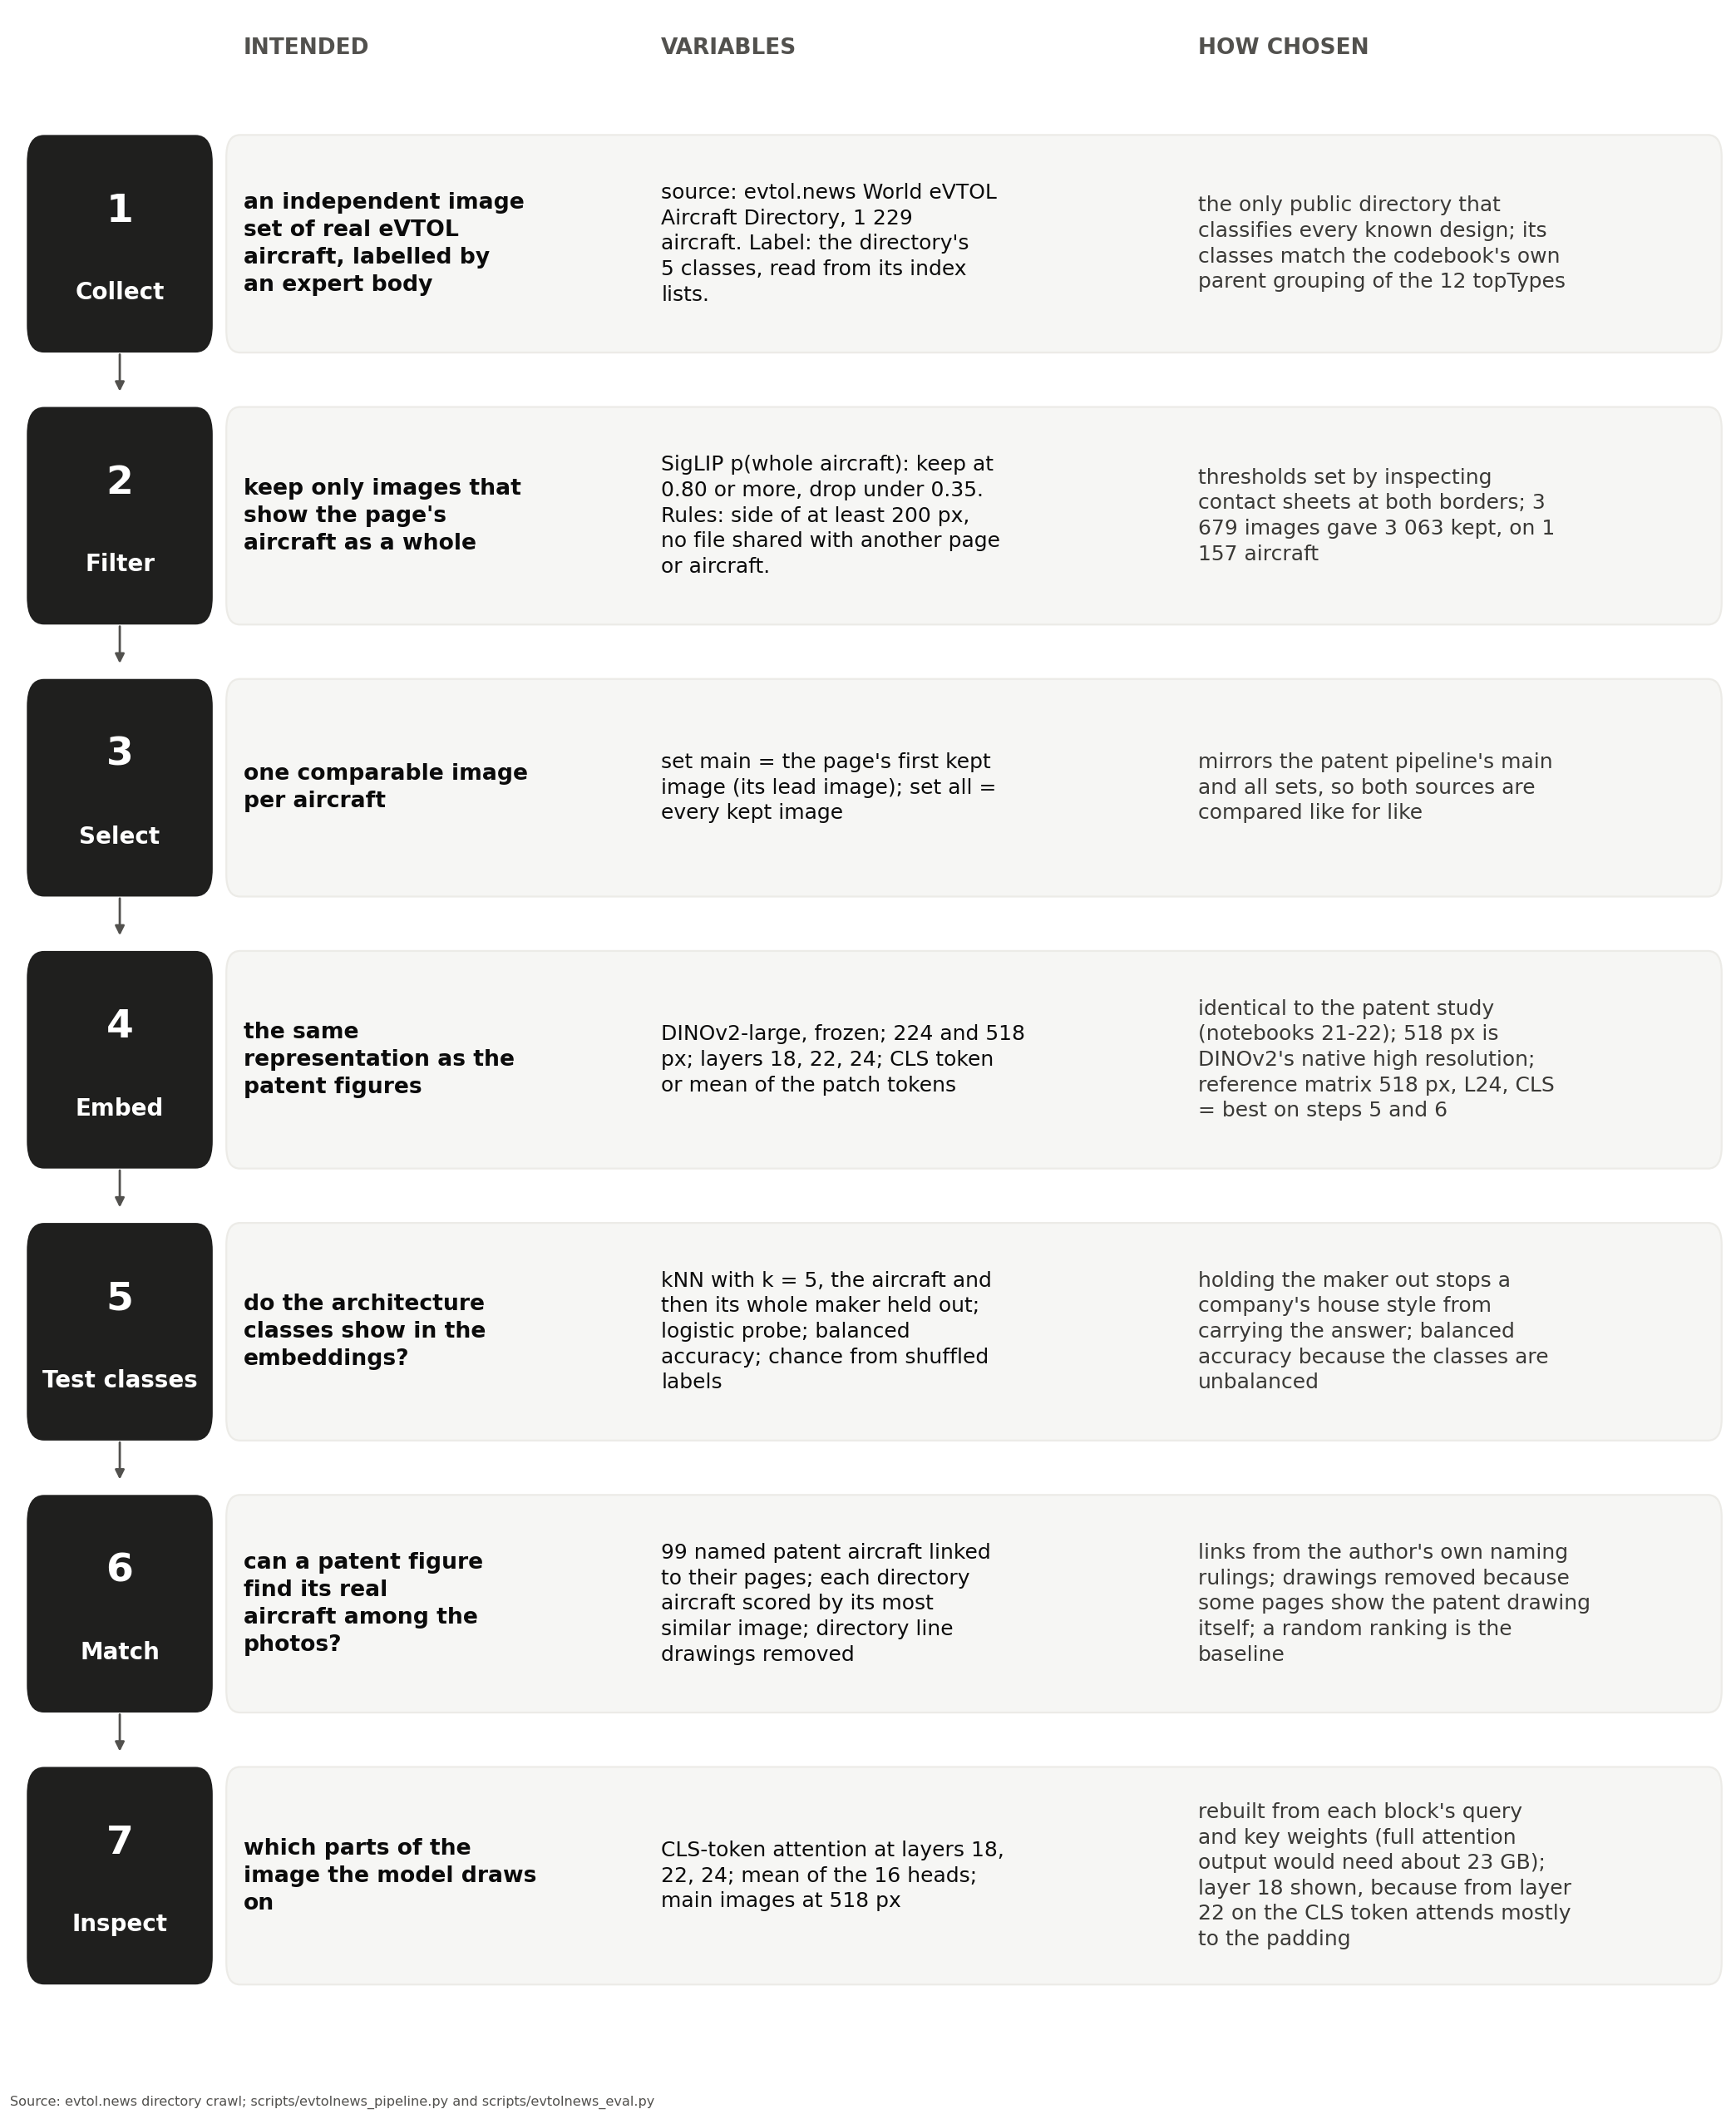

**f16_umap_joint**

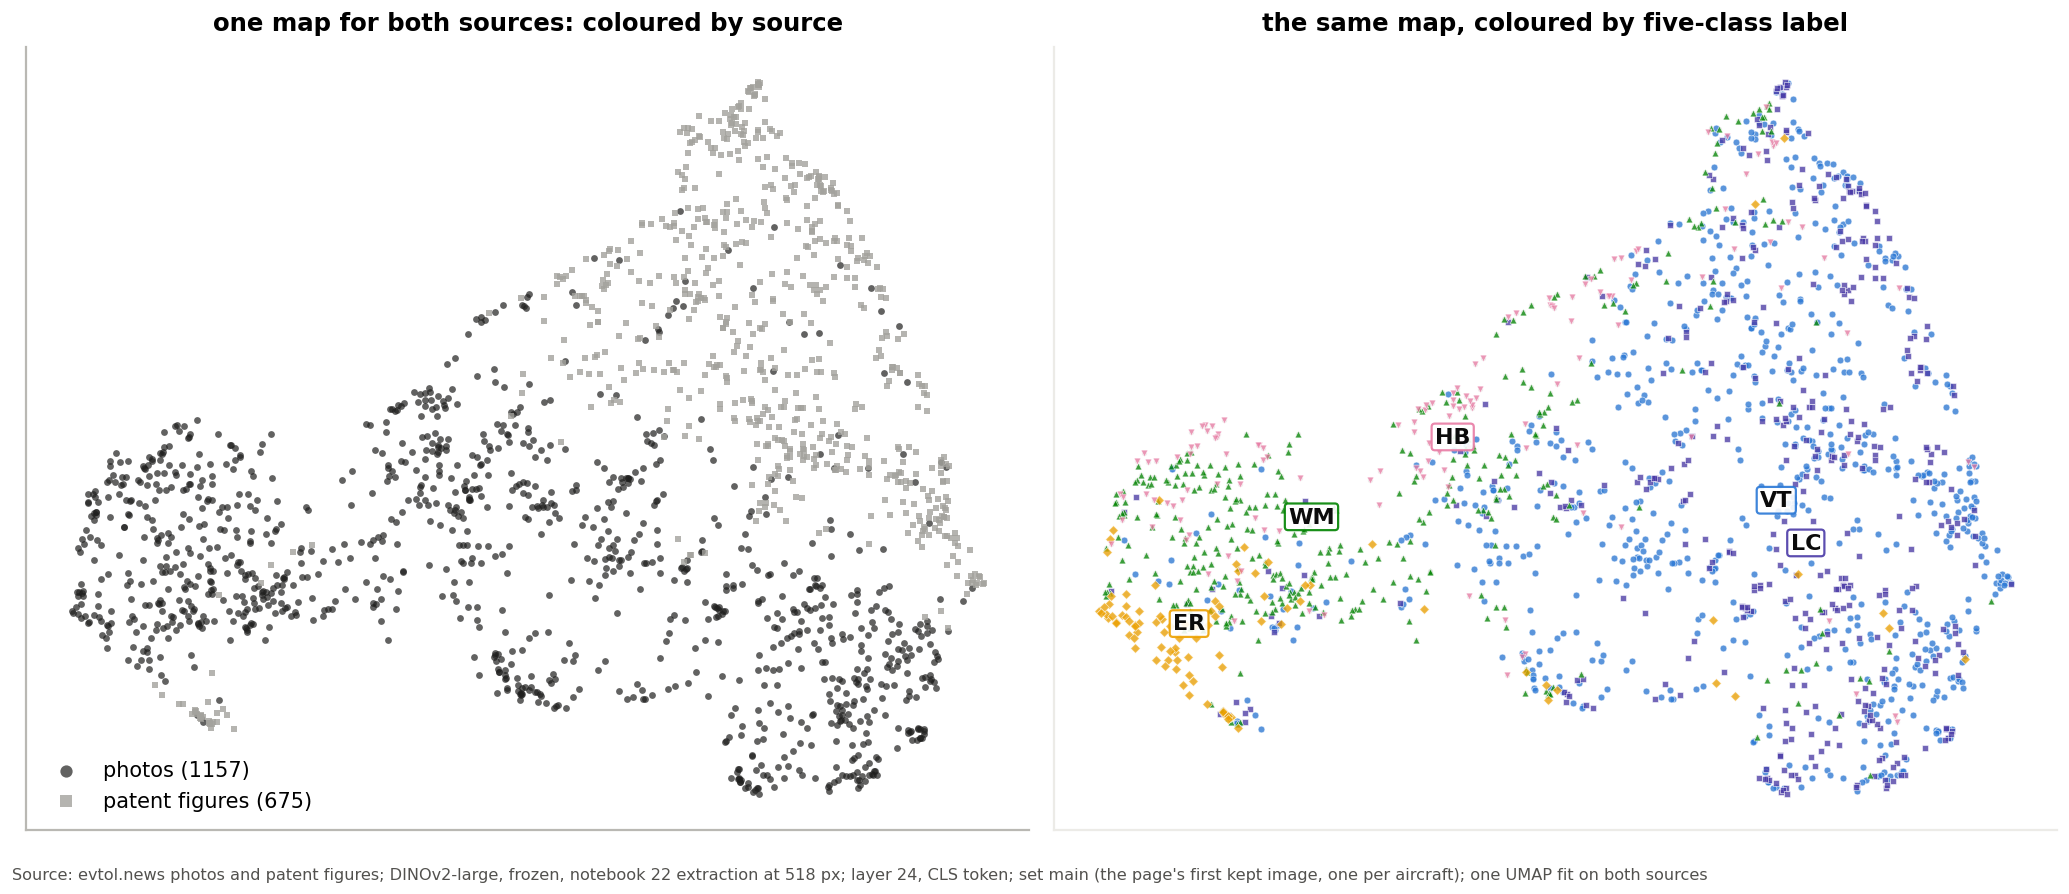

**f28_attention_pairs**

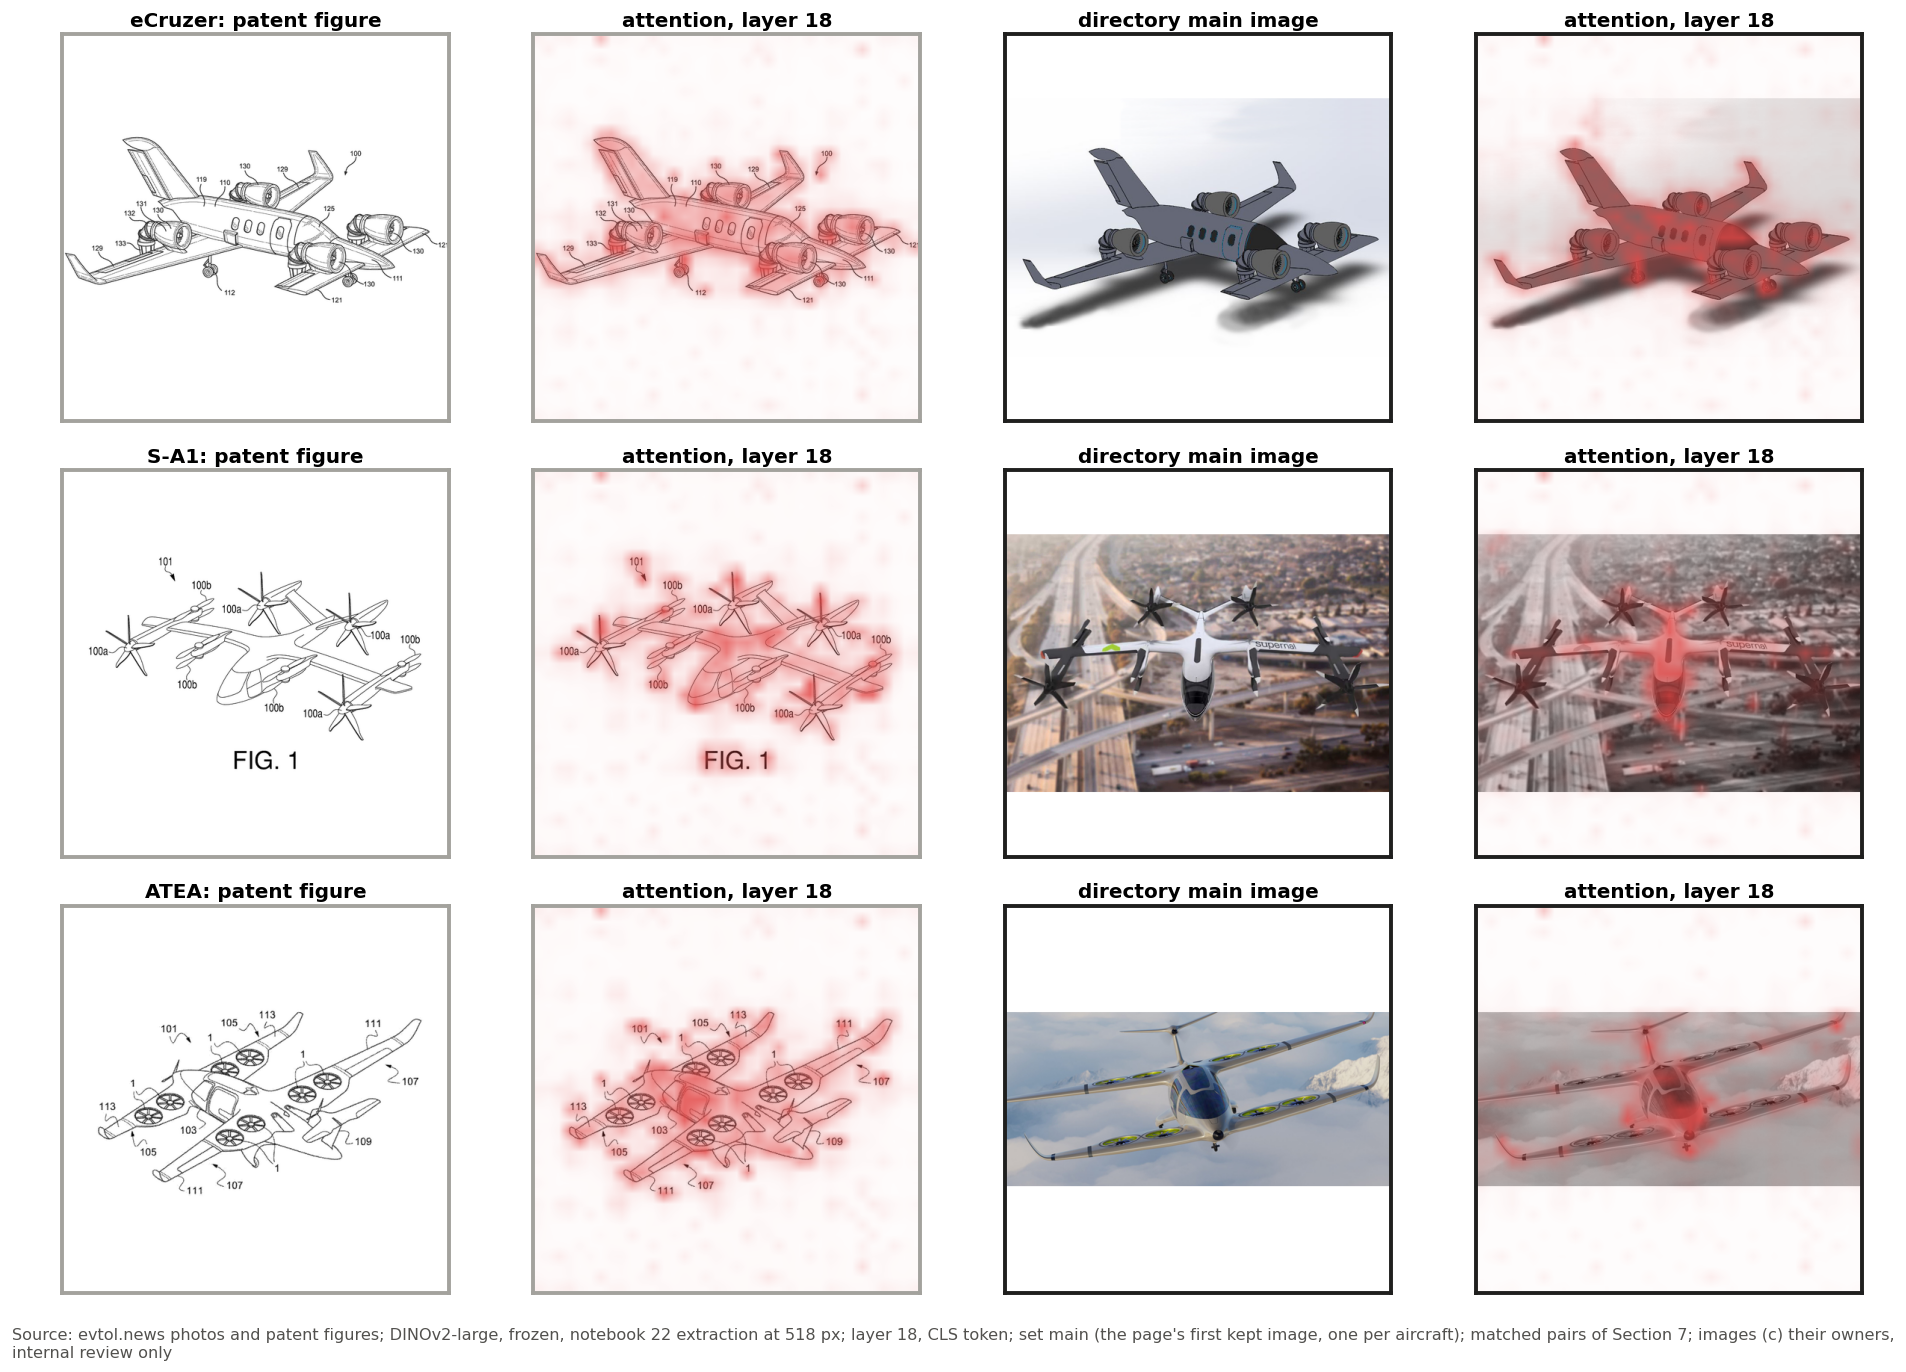

**f29_attention_collapse**

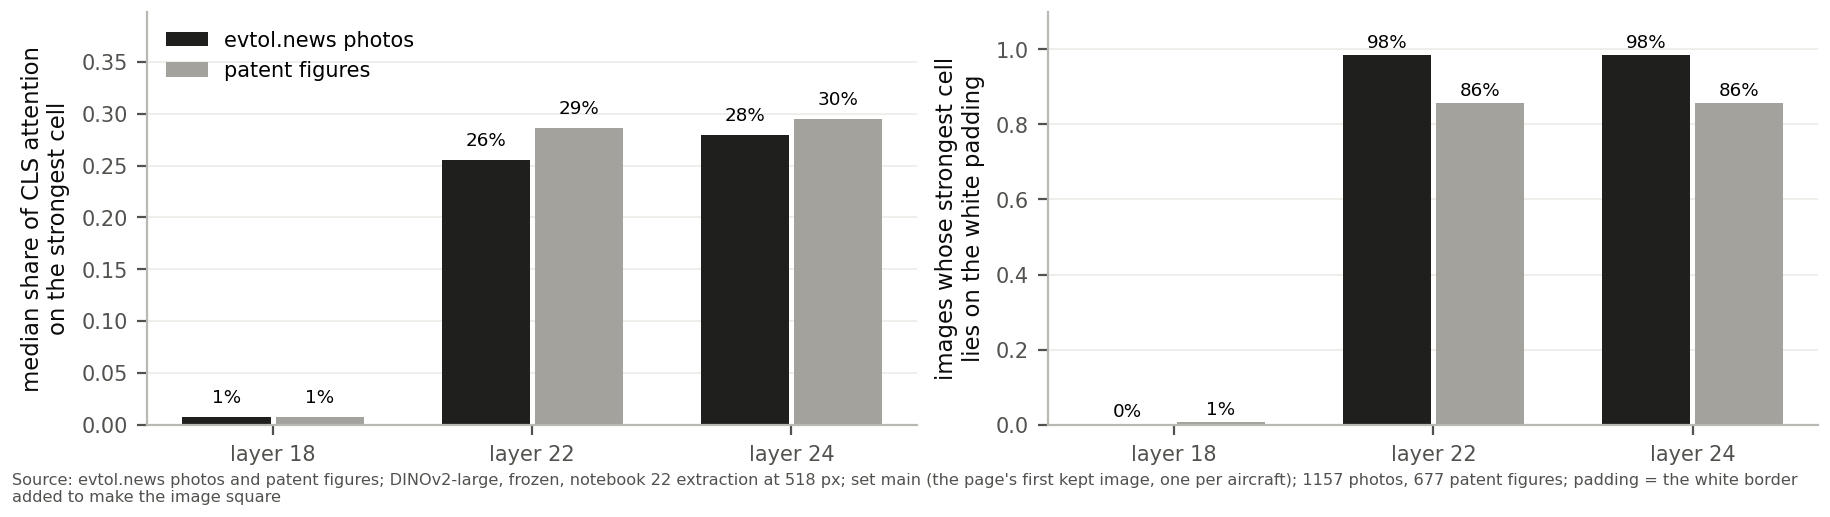

In [9]:
for key in ['f00_method', 'f16_umap_joint', 'f28_attention_pairs', 'f29_attention_collapse']:
    display(Markdown(f"**{key}**"))
    display(Image(filename=str(out / 'advisor_report' / 'figs' / f'{key}.png'), width=900))